Grafico de Call

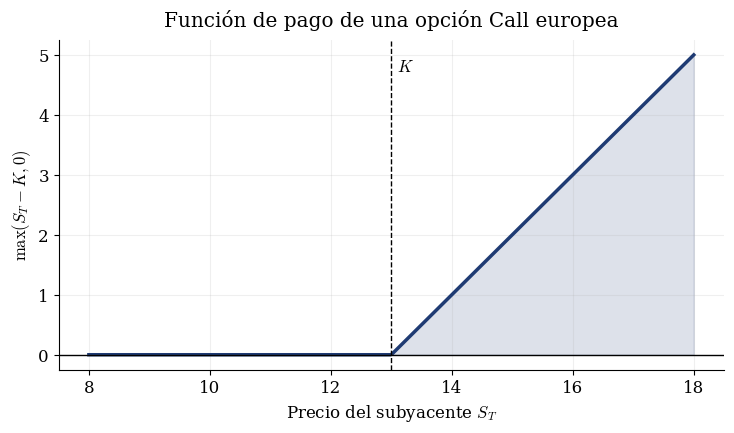

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
K = 13
S = np.linspace(8, 18, 500)
call = np.maximum(S - K, 0)

# Estilo
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Curva
ax.plot(S, call, color="#1f3b73", linewidth=2.5)

# Sombreado
ax.fill_between(S, call, where=(S >= K), alpha=0.15, color="#1f3b73")

# Líneas clave
ax.axvline(K, linestyle='--', color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=1)

# Etiquetas
ax.set_title("Función de pago de una opción Call europea", pad=10)
ax.set_xlabel(r"Precio del subyacente $S_T$")
ax.set_ylabel(r"$\max(S_T - K, 0)$")

# K visible (con fondo blanco)
ax.text(K + 0.1, ax.get_ylim()[1]*0.9, r"$K$",
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("call_final.pdf", dpi=300)
plt.show()

Opcion Put

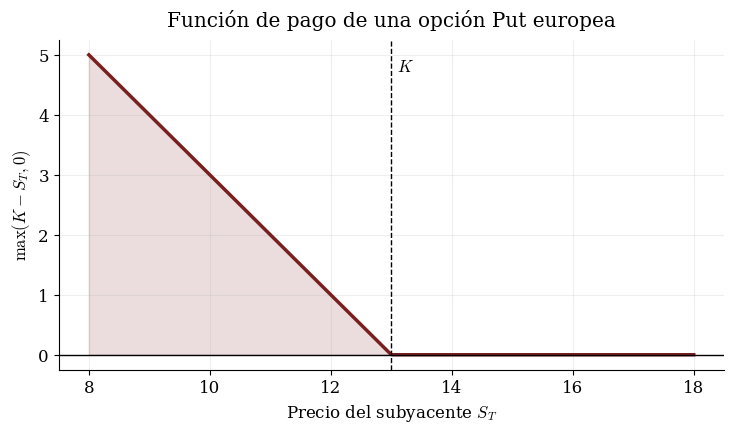

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
K = 13
S = np.linspace(8, 18, 500)
put = np.maximum(K - S, 0)

# Estilo
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Curva
ax.plot(S, put, color="#7a1f1f", linewidth=2.5)

# Sombreado
ax.fill_between(S, put, where=(S <= K), alpha=0.15, color="#7a1f1f")

# Líneas clave
ax.axvline(K, linestyle='--', color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=1)

# Etiquetas
ax.set_title("Función de pago de una opción Put europea", pad=10)
ax.set_xlabel(r"Precio del subyacente $S_T$")
ax.set_ylabel(r"$\max(K - S_T, 0)$")

# K visible (con fondo blanco)
ax.text(K + 0.1, ax.get_ylim()[1]*0.9, r"$K$",
        ha='left',
        bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Estética
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("put_final.pdf", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Nodos
nodos = {
    'S':  (2, 5),
    'Su': (6, 7.5),
    'Sd': (6, 2.5),
}

opciones = {
    'Vu': (9, 7.5),
    'Vd': (9, 2.5),
}

# Dibujar flechas entre nodos
for destino in ['Su', 'Sd']:
    x0, y0 = nodos['S']
    x1, y1 = nodos[destino]
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Flechas hacia valores de opción
for origen, destino in [('Su', 'Vu'), ('Sd', 'Vd')]:
    x0, y0 = nodos[origen]
    x1, y1 = opciones[destino]
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='gray', 
                                lw=1.2, linestyle='dashed'))

# Etiquetas de nodos del activo
etiquetas_nodos = {
    'S':  r'$S = 100$',
    'Su': r'$uS = 110$',
    'Sd': r'$dS = 90$',
}

for key, (x, y) in nodos.items():
    ax.annotate(etiquetas_nodos[key], xy=(x, y),
                fontsize=13, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.4', fc='#dce8f5', ec='#2c6fad', lw=1.5))

# Etiquetas de valores de opción
etiquetas_opciones = {
    'Vu': r'$V_u = 10$',
    'Vd': r'$V_d = 0$',
}

for key, (x, y) in opciones.items():
    ax.annotate(etiquetas_opciones[key], xy=(x, y),
                fontsize=13, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.4', fc='#e8f5e0', ec='#4a7c3f', lw=1.5))

# Etiquetas de probabilidades en las flechas
ax.text(3.8, 6.7, r'$p \approx 0.756$', fontsize=11, color='#2c6fad')
ax.text(3.8, 3.1, r'$1-p \approx 0.244$', fontsize=11, color='#2c6fad')

# Etiquetas de tiempo
ax.text(2,   1.5, r'$t = 0$',   fontsize=11, ha='center', color='gray')
ax.text(6,   1.5, r'$t = \tau$', fontsize=11, ha='center', color='gray')
ax.text(9,   1.5, r'Flujo',      fontsize=11, ha='center', color='gray')

# Valor de la opción
ax.text(2, 3.8, r'$V \approx 7.19$', fontsize=11, ha='center',
        color='#8b0000',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#8b0000', lw=1.2))

plt.title('Árbol binomial de un periodo — Opción call con $K = 100$',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('arbol_binomial.png', dpi=200, bbox_inches='tight')
plt.show()